<a href="https://colab.research.google.com/github/DARIEMBV/Agente_AntiBots_Uma/blob/main/agente_antibots_uma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Asignatura: Aplicación en IA · Diseño ·Agente Antibots y suplantación de biometricos· WomenCiso México

Equipo: UMA

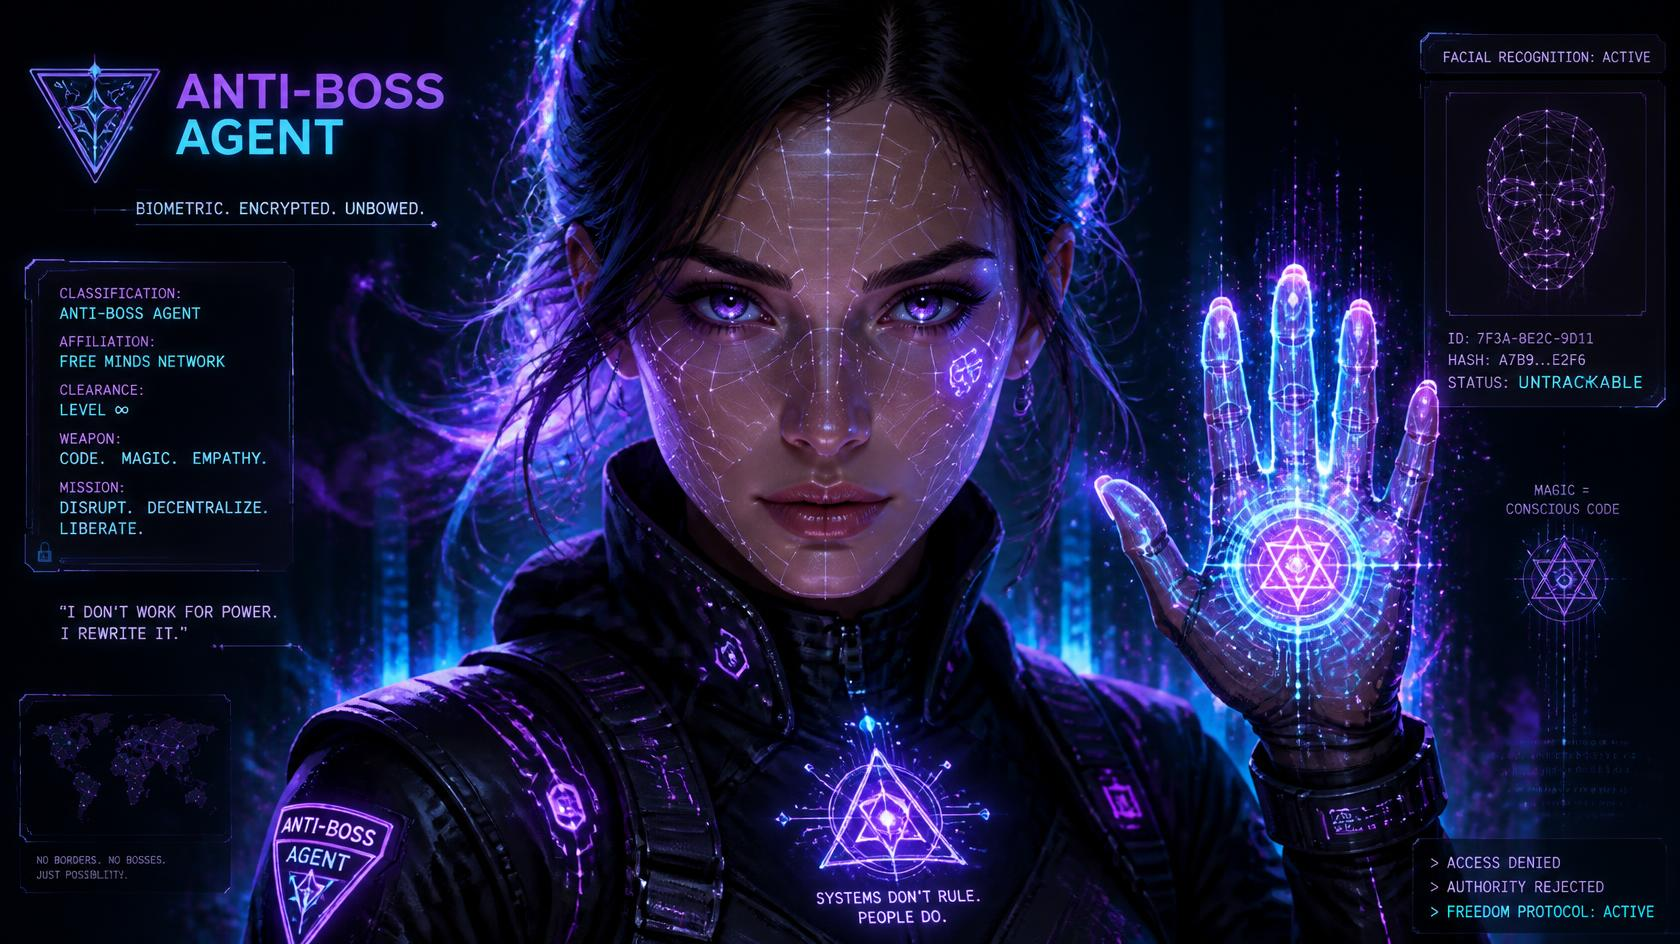




Objetivo: Desarrollar una aplicación de visión por computadora capaz de analizar imágenes faciales en tiempo real mediante detección de landmarks, procesamiento de características visuales y análisis de textura para apoyar procesos de verificación biométrica y prueba de vida.

Ejemplo 1: Aplicación de IA con Gemeni para realizar el Diseño de Agente con Notebook Colab.

Integra Detección Facial.

Identificación de Faciales.

Análisis de textura y características de la imagen.

cálculo de métricas y puntuaciones de evaluación.

Generación de alertas ante condiciones anómalas.

Visualización mediante HUD y telemetría en tiempo real.

Integración de información de geolocalización como contexto adicional de validación.

Proximos Pasos: Mejora Estática , validación dermo-temporal, ventana de amortiguamiento temporal:impidiendo bloquear o congelar de forma preventiva operaciones de alto riesgo antes de que se consuma el fraude y prevención de inyección inmediata MCP Multi-Party Computation by Google Colaboratory.

In [ ]:
# ============================================================
# BIOGUARD SENTINEL
# AGENTE ANTIBOT ADAPTATIVO
# LIVENESS + EVIDENCIA MULTIFRAME + MALLA 3D
# ============================================================

!pip install -q mediapipe gradio opencv-python-headless pillow ultralytics

# ============================================================
# 1. IMPORTACIONES
# ============================================================

import cv2
import numpy as np
import urllib.request
import os
import time
import random
import math
import gradio as gr
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from ultralytics import YOLO


# ============================================================
# 2. DESCARGA DE MODELOS
# ============================================================

MODEL_PATH = "face_landmarker.task"

if not os.path.exists(MODEL_PATH):

    MODEL_URL = (
        "https://storage.googleapis.com/"
        "mediapipe-models/face_landmarker/"
        "face_landmarker/float16/1/"
        "face_landmarker.task"
    )

    print("Descargando modelo Face Landmarker...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Modelo descargado correctamente.")


print("Cargando modelo YOLOv8n...")
yolo_model = YOLO("yolov8n.pt")


# ============================================================
# 3. CONFIGURACIÓN MEDIAPIPE
# ============================================================

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=False,
    num_faces=1,
    running_mode=vision.RunningMode.VIDEO
)

detector = vision.FaceLandmarker.create_from_options(options)


# ============================================================
# 4. VARIABLES GLOBALES
# ============================================================

SISTEMA_ACTIVO = True
LAST_PROCESS_TIME = 0
FRAME_TIMESTAMP = 0

CACHE_HUD = np.zeros(
    (180, 260, 3),
    dtype=np.uint8
)

CACHE_MESH = np.zeros(
    (360, 480, 3),
    dtype=np.uint8
)


# ============================================================
# 5. ESTADO DEL AGENTE
# ============================================================

def crear_estado_inicial():

    return {

        "fase": "INICIO",

        "prueba_actual": None,

        "pruebas_realizadas": [],

        "pruebas_exitosas": [],

        "pruebas_fallidas": [],

        "evidencia_humana": 0.0,

        "riesgo_bot": 0.0,

        "riesgo_deepfake": 0.0,

        "intentos": 0,

        "decision": "INICIANDO",

        "inicio_prueba": time.time(),

        "prueba_evaluada": False,

        # ----------------------------
        # Métricas actuales
        # ----------------------------

        "sonrisa": 0.0,

        "parpadeo_izq": 0.0,

        "parpadeo_der": 0.0,

        "orientacion": "CENTRO",

        "menton": "CENTRO",

        "inclinacion": "RECTA",

        # ----------------------------
        # Confirmación temporal
        # ----------------------------

        "frames_validos": 0,

        "frames_invalidos": 0,

        "frames_cerrados": 0,

        "frames_abiertos_despues": 0,

        "blink_detectado": False,

        # ----------------------------
        # Control de prueba
        # ----------------------------

        "ultimo_resultado": None,

        "ultima_prueba_completada": None,

        "mensaje": "Esperando rostro..."
    }


ESTADO_AGENTE = crear_estado_inicial()


PRUEBAS_DISPONIBLES = [

    "SONRISA",

    "PARPADEO",

    "MIRA_DERECHA",

    "MIRA_IZQUIERDA",

    "ELEVA_MENTON",

    "INCLINA_CABEZA"
]


# ============================================================
# 6. LANDMARKS FACIALES
# ============================================================

LEFT_EYE_TOP = 159
LEFT_EYE_BOTTOM = 145
LEFT_EYE_LEFT = 33
LEFT_EYE_RIGHT = 133

RIGHT_EYE_TOP = 386
RIGHT_EYE_BOTTOM = 374
RIGHT_EYE_LEFT = 362
RIGHT_EYE_RIGHT = 263

MOUTH_LEFT = 61
MOUTH_RIGHT = 291
MOUTH_TOP = 13
MOUTH_BOTTOM = 14

NOSE_TIP = 1

FACE_LEFT = 234
FACE_RIGHT = 454
FACE_TOP = 10
FACE_BOTTOM = 152


# ============================================================
# 7. MALLA HUMANA 3D
# ============================================================

def generar_malla_humana_3d(
    landmarks,
    w,
    h,
    color_bgr=(0, 255, 136)
):

    canvas_synth = np.zeros(
        (360, 480, 3),
        dtype=np.uint8
    )

    if not landmarks:
        return canvas_synth

    puntos = []

    for lm in landmarks:

        z_scale = max(
            0.2,
            1.0 + lm.z
        )

        cx = int(
            (lm.x - 0.5)
            * 480
            / z_scale
            + 240
        )

        cy = int(
            (lm.y - 0.5)
            * 360
            / z_scale
            + 180
        )

        puntos.append((cx, cy))

        cv2.circle(
            canvas_synth,
            (cx, cy),
            1,
            color_bgr,
            -1
        )

    for i in range(
        0,
        len(puntos) - 2,
        2
    ):

        cv2.line(
            canvas_synth,
            puntos[i],
            puntos[i + 2],
            color_bgr,
            1
        )

    return canvas_synth


# ============================================================
# 8. MALLA FELINA (EXACTA A LA REFERENCIA)
# ============================================================

def draw_cat_facial_mesh(
    canvas,
    bbox
):

    x1, y1, x2, y2 = bbox
    w_box = x2 - x1
    h_box = y2 - y1

    nodes = {
        "oreja_izq": (int(x1 + w_box * 0.15), int(y1 + h_box * 0.30)),
        "oreja_der": (int(x1 + w_box * 0.85), int(y1 + h_box * 0.30)),
        "centro_superior": (int(x1 + w_box * 0.60), int(y1 + h_box * 0.45)),
        "centro_medio": (int(x1 + w_box * 0.60), int(y1 + h_box * 0.70)),
        "izq_inferior": (int(x1 + w_box * 0.42), int(y1 + h_box * 0.75)),
        "der_inferior": (int(x1 + w_box * 0.80), int(y1 + h_box * 0.75))
    }

    lines = [
        ("oreja_izq", "centro_superior"),
        ("oreja_der", "centro_superior"),
        ("centro_superior", "centro_medio"),
        ("centro_medio", "izq_inferior"),
        ("centro_medio", "der_inferior"),
        ("izq_inferior", "der_inferior")
    ]

    for p1, p2 in lines:
        cv2.line(
            canvas,
            nodes[p1],
            nodes[p2],
            (0, 180, 255),
            2,
            cv2.LINE_AA
        )

    for name, pt in nodes.items():
        cv2.circle(
            canvas,
            pt,
            4,
            (0, 255, 255),
            -1
        )

    # Etiqueta de Error idéntica a la referencia visual
    cv2.rectangle(canvas, (int(x1 + w_box * 0.35), int(y1 + h_box * 0.42)), (int(x1 + w_box * 0.65), int(y1 + h_box * 0.58)), (255, 255, 255), -1)
    cv2.rectangle(canvas, (int(x1 + w_box * 0.35), int(y1 + h_box * 0.42)), (int(x1 + w_box * 0.65), int(y1 + h_box * 0.58)), (0, 0, 255), 1)
    cv2.putText(
        canvas,
        "Error",
        (int(x1 + w_box * 0.40), int(y1 + h_box * 0.53)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        2,
        cv2.LINE_AA
    )


# ============================================================
# 9. FUNCIONES GEOMÉTRICAS Y OCLUSIÓN
# ============================================================

def distancia(p1, p2):

    return math.sqrt(
        (p1.x - p2.x) ** 2
        +
        (p1.y - p2.y) ** 2
    )


def analizar_oclusion(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    brillo_medio = np.mean(gray)
    if brillo_medio < 12.0:
        return True
    return False


# ============================================================
# 10. EAR
# ============================================================

def calcular_eye_aspect_ratio(
    landmarks,
    top,
    bottom,
    left,
    right
):

    vertical = distancia(
        landmarks[top],
        landmarks[bottom]
    )

    horizontal = distancia(
        landmarks[left],
        landmarks[right]
    )

    if horizontal == 0:
        return 0.0

    return vertical / horizontal


def analizar_parpadeo(landmarks):

    ear_left = calcular_eye_aspect_ratio(
        landmarks,
        LEFT_EYE_TOP,
        LEFT_EYE_BOTTOM,
        LEFT_EYE_LEFT,
        LEFT_EYE_RIGHT
    )

    ear_right = calcular_eye_aspect_ratio(
        landmarks,
        RIGHT_EYE_TOP,
        RIGHT_EYE_BOTTOM,
        RIGHT_EYE_LEFT,
        RIGHT_EYE_RIGHT
    )

    blink_left = 1.0 if ear_left < 0.22 else 0.0
    blink_right = 1.0 if ear_right < 0.22 else 0.0

    return (
        ear_left,
        ear_right,
        blink_left,
        blink_right
    )


# ============================================================
# 11. SONRISA
# ============================================================

def analizar_sonrisa(landmarks):

    horizontal = distancia(
        landmarks[MOUTH_LEFT],
        landmarks[MOUTH_RIGHT]
    )

    vertical = distancia(
        landmarks[MOUTH_TOP],
        landmarks[MOUTH_BOTTOM]
    )

    if horizontal == 0:
        return 0.0

    ratio = vertical / horizontal

    score = np.clip(
        (ratio - 0.08) / 0.14,
        0.0,
        1.0
    )

    return float(score)


# ============================================================
# 12. ORIENTACIÓN
# ============================================================

def analizar_orientacion(landmarks):

    left = landmarks[FACE_LEFT]
    right = landmarks[FACE_RIGHT]
    nose = landmarks[NOSE_TIP]

    face_width = right.x - left.x

    if abs(face_width) < 0.0001:
        return "CENTRO", 0.5

    relative = (
        nose.x - left.x
    ) / face_width

    if relative > 0.56:

        return "DERECHA", relative

    elif relative < 0.44:

        return "IZQUIERDA", relative

    return "CENTRO", relative


# ============================================================
# 13. MENTÓN
# ============================================================

def analizar_menton(landmarks):

    top = landmarks[FACE_TOP]
    bottom = landmarks[FACE_BOTTOM]
    nose = landmarks[NOSE_TIP]

    face_height = bottom.y - top.y

    if abs(face_height) < 0.0001:
        return "CENTRO"

    relative = (
        nose.y - top.y
    ) / face_height

    if relative < 0.46:

        return "MENTON_ARRIBA"

    elif relative > 0.56:

        return "MENTON_ABAJO"

    return "CENTRO"


# ============================================================
# 14. INCLINACIÓN
# ============================================================

def analizar_inclinacion(landmarks):

    left = landmarks[FACE_LEFT]
    right = landmarks[FACE_RIGHT]

    angle = math.degrees(
        math.atan2(
            right.y - left.y,
            right.x - left.x
        )
    )

    if abs(angle) > 7:

        return "INCLINADA"

    return "RECTA"


# ============================================================
# 15. BALANCE DE LUZ
# ============================================================

def analizar_balance_luz(
    frame,
    landmarks,
    w,
    h
):

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    left_x = int(
        landmarks[FACE_LEFT].x * w
    )

    right_x = int(
        landmarks[FACE_RIGHT].x * w
    )

    left_x = max(
        0,
        min(w - 1, left_x)
    )

    right_x = max(
        0,
        min(w, right_x)
    )

    if right_x <= left_x:

        return 50.0, 50.0, 1.0

    mid_x = (
        left_x + right_x
    ) // 2

    patch_izq = gray[
        :,
        left_x:mid_x
    ]

    patch_der = gray[
        :,
        mid_x:right_x
    ]

    val_izq = (
        float(np.mean(patch_izq))
        if patch_izq.size > 0
        else 50.0
    )

    val_der = (
        float(np.mean(patch_der))
        if patch_der.size > 0
        else 50.0
    )

    diff = abs(
        val_izq - val_der
    )

    score = float(
        np.clip(
            1.0 - diff / 100.0,
            0.0,
            1.0
        )
    )

    return (
        val_izq,
        val_der,
        score
    )


# ============================================================
# 16. TEXTURA
# ============================================================

def analizar_textura(
    frame,
    landmarks,
    w,
    h
):

    punto = landmarks[117]

    cx = int(
        punto.x * w
    )

    cy = int(
        punto.y * h
    )

    patch = frame[
        max(0, cy - 25):
        min(h, cy + 25),

        max(0, cx - 25):
        min(w, cx + 25)
    ]

    if patch.size == 0:

        return {

            "sobel": 0.0,

            "score_textura": 0.0,

            "laplaciano": 0.0,

            "score_ruido": 0.0,

            "sello": "Sin datos"
        }

    gray_patch = cv2.cvtColor(
        patch,
        cv2.COLOR_BGR2GRAY
    )

    sobel = np.mean(
        np.abs(
            cv2.Sobel(
                gray_patch,
                cv2.CV_64F,
                1,
                1,
                ksize=3
            )
        )
    )

    score_textura = float(
        np.clip(
            sobel / 50.0,
            0.0,
            1.0
        )
    )

    laplaciano = cv2.Laplacian(
        gray_patch,
        cv2.CV_64F
    ).var()

    score_ruido = (
        1.0
        if 15.0 < laplaciano < 800.0
        else 0.2
    )

    if laplaciano > 350:

        sello = (
            "Posible lunar, mancha "
            "o quemadura localizada"
        )

    elif laplaciano < 40:

        sello = (
            "Zona homogénea "
            "(Sin marcas aparentes)"
        )

    else:

        sello = (
            "Rasgo dérmico estándar "
            "verificado"
        )

    return {

        "sobel": float(sobel),

        "score_textura":
            score_textura,

        "laplaciano":
            float(laplaciano),

        "score_ruido":
            float(score_ruido),

        "sello":
            sello
    }


# ============================================================
# 17. TEXTO DE INSTRUCCIONES
# ============================================================

def texto_prueba(prueba):

    instrucciones = {

        "SONRISA":
            "🙂 SONRÍE",

        "PARPADEO":
            "😉 PARPADEA",

        "MIRA_DERECHA":
            "➡️ MIRA A LA DERECHA",

        "MIRA_IZQUIERDA":
            "⬅️ MIRA A LA IZQUIERDA",

        "ELEVA_MENTON":
            "⬆️ ELEVA EL MENTÓN",

        "INCLINA_CABEZA":
            "↗️ INCLINA LA CABEZA"
    }

    return instrucciones.get(
        prueba,
        "ESPERANDO INSTRUCCIÓN..."
    )


# ============================================================
# 18. REINICIO REAL DEL AGENTE
# ============================================================

def reiniciar_estado_agente():

    global ESTADO_AGENTE
    global CACHE_HUD
    global CACHE_MESH
    global FRAME_TIMESTAMP
    global LAST_PROCESS_TIME

    ESTADO_AGENTE = crear_estado_inicial()

    CACHE_HUD = np.zeros(
        (180, 260, 3),
        dtype=np.uint8
    )

    CACHE_MESH = np.zeros(
        (360, 480, 3),
        dtype=np.uint8
    )

    FRAME_TIMESTAMP = 0

    LAST_PROCESS_TIME = 0


# ============================================================
# 19. SELECCIÓN DE PRUEBA
# ============================================================

def seleccionar_siguiente_prueba():

    realizadas = (
        ESTADO_AGENTE[
            "pruebas_realizadas"
        ]
    )

    disponibles = [

        p

        for p in PRUEBAS_DISPONIBLES

        if p not in realizadas
    ]

    if not disponibles:

        disponibles = (
            PRUEBAS_DISPONIBLES.copy()
        )

    anterior = (
        ESTADO_AGENTE[
            "prueba_actual"
        ]
    )

    opciones = [

        p

        for p in disponibles

        if p != anterior
    ]

    if not opciones:

        opciones = disponibles

    return random.choice(
        opciones
    )


# ============================================================
# 20. INICIAR NUEVO DESAFÍO
# ============================================================

def iniciar_nuevo_desafio():

    prueba = seleccionar_siguiente_prueba()

    ESTADO_AGENTE[
        "prueba_actual"
    ] = prueba

    ESTADO_AGENTE[
        "fase"
    ] = "DESAFIO"

    ESTADO_AGENTE[
        "inicio_prueba"
    ] = time.time()

    ESTADO_AGENTE[
        "prueba_evaluada"
    ] = False

    ESTADO_AGENTE[
        "frames_validos"
    ] = 0

    ESTADO_AGENTE[
        "frames_invalidos"
    ] = 0

    ESTADO_AGENTE[
        "frames_cerrados"
    ] = 0

    ESTADO_AGENTE[
        "frames_abiertos_despues"
    ] = 0

    ESTADO_AGENTE[
        "blink_detectado"
    ] = False

    ESTADO_AGENTE[
        "ultimo_resultado"
    ] = None

    if prueba not in ESTADO_AGENTE[
        "pruebas_realizadas"
    ]:

        ESTADO_AGENTE[
            "pruebas_realizadas"
        ].append(prueba)

    return prueba


# ============================================================
# 21. EVALUACIÓN MULTIFRAME
# ============================================================

def evaluar_prueba(
    prueba,
    sonrisa,
    blink_left,
    blink_right,
    orientacion,
    menton,
    inclinacion
):

    estado = ESTADO_AGENTE

    if prueba == "SONRISA":

        if sonrisa >= 0.35:

            estado[
                "frames_validos"
            ] += 1

            estado[
                "frames_invalidos"
            ] = 0

        else:

            estado[
                "frames_invalidos"
            ] += 1

            estado[
                "frames_validos"
            ] = max(
                0,
                estado[
                    "frames_validos"
                ] - 1
            )

        return (
            estado["frames_validos"] >= 5,
            estado["frames_validos"]
        )

    if prueba == "PARPADEO":

        ojo_cerrado = (
            blink_left == 1
            or
            blink_right == 1
        )

        if ojo_cerrado:

            estado[
                "frames_cerrados"
            ] += 1

        else:

            if estado[
                "frames_cerrados"
            ] >= 2:

                estado[
                    "frames_abiertos_despues"
                ] += 1

            else:

                estado[
                    "frames_abiertos_despues"
                ] = 0

        if (
            estado["frames_cerrados"] >= 2
            and
            estado[
                "frames_abiertos_despues"
            ] >= 2
        ):

            estado[
                "blink_detectado"
            ] = True

        return (
            estado[
                "blink_detectado"
            ],
            estado[
                "frames_cerrados"
            ]
        )

    if prueba == "MIRA_DERECHA":

        if orientacion == "DERECHA":

            estado[
                "frames_validos"
            ] += 1

        else:

            estado[
                "frames_validos"
            ] = max(
                0,
                estado[
                    "frames_validos"
                ] - 1
            )

        return (
            estado["frames_validos"] >= 5,
            estado["frames_validos"]
        )

    if prueba == "MIRA_IZQUIERDA":

        if orientacion == "IZQUIERDA":

            estado[
                "frames_validos"
            ] += 1

        else:

            estado[
                "frames_validos"
            ] = max(
                0,
                estado[
                    "frames_validos"
                ] - 1
            )

        return (
            estado["frames_validos"] >= 5,
            estado["frames_validos"]
        )

    if prueba == "ELEVA_MENTON":

        if menton == "MENTON_ARRIBA":

            estado[
                "frames_validos"
            ] += 1

        else:

            estado[
                "frames_validos"
            ] = max(
                0,
                estado[
                    "frames_validos"
                ] - 1
            )

        return (
            estado["frames_validos"] >= 5,
            estado["frames_validos"]
        )

    if prueba == "INCLINA_CABEZA":

        if inclinacion == "INCLINADA":

            estado[
                "frames_validos"
            ] += 1

        else:

            estado[
                "frames_validos"
            ] = max(
                0,
                estado[
                    "frames_validos"
                ] - 1
            )

        return (
            estado["frames_validos"] >= 5,
            estado["frames_validos"]
        )

    return False, 0


# ============================================================
# 22. ACTUALIZAR EVIDENCIA
# ============================================================

def actualizar_agente(
    resultado,
    score_textura,
    score_ruido
):

    prueba = (
        ESTADO_AGENTE[
            "prueba_actual"
        ]
    )

    if not prueba:
        return

    if resultado:

        ESTADO_AGENTE[
            "evidencia_humana"
        ] += 1.0

        ESTADO_AGENTE[
            "evidencia_humana"
        ] = min(
            ESTADO_AGENTE[
                "evidencia_humana"
            ],
            3.0
        )

        ESTADO_AGENTE[
            "riesgo_bot"
        ] = max(
            0.0,
            ESTADO_AGENTE[
                "riesgo_bot"
            ] - 0.40
        )

        if prueba not in ESTADO_AGENTE[
            "pruebas_exitosas"
        ]:

            ESTADO_AGENTE[
                "pruebas_exitosas"
            ].append(prueba)

        ESTADO_AGENTE[
            "decision"
        ] = "HUMANO"

        ESTADO_AGENTE[
            "ultimo_resultado"
        ] = "EXITOSA"

    else:

        ESTADO_AGENTE[
            "riesgo_bot"
        ] += 0.65

        if prueba not in ESTADO_AGENTE[
            "pruebas_fallidas"
        ]:

            ESTADO_AGENTE[
                "pruebas_fallidas"
            ].append(prueba)

        ESTADO_AGENTE[
            "decision"
        ] = "PRUEBA NO CONFIRMADA"

        ESTADO_AGENTE[
            "ultimo_resultado"
        ] = "FALLIDA"

    if score_textura >= 0.60:

        ESTADO_AGENTE[
            "evidencia_humana"
        ] += 0.20

    else:

        ESTADO_AGENTE[
            "riesgo_deepfake"
        ] += 0.10

    if score_ruido >= 0.40:

        ESTADO_AGENTE[
            "evidencia_humana"
        ] += 0.10

    else:

        ESTADO_AGENTE[
            "riesgo_deepfake"
        ] += 0.30

    ESTADO_AGENTE[
        "evidencia_humana"
    ] = min(
        ESTADO_AGENTE[
            "evidencia_humana"
        ],
        3.0
    )


# ============================================================
# 23. DECISIÓN DEL AGENTE
# ============================================================

def agente_decidir():

    estado = ESTADO_AGENTE

    if (
        len(
            estado["pruebas_exitosas"]
        ) >= 2
        and
        estado[
            "evidencia_humana"
        ] >= 1.8
    ):

        estado[
            "fase"
        ] = "VERIFICADO"

        estado[
            "decision"
        ] = "HUMANO"

        return "FINALIZAR"

    if (
        estado[
            "riesgo_deepfake"
        ] >= 3.0
    ):

        estado[
            "fase"
        ] = "RIESGO"

        estado[
            "decision"
        ] = "DEEPFAKE"

        return "FINALIZAR"

    if (
        estado[
            "riesgo_bot"
        ] >= 3.0
        or
        len(
            estado["pruebas_fallidas"]
        ) >= 3
    ):

        estado[
            "fase"
        ] = "RIESGO"

        estado[
            "decision"
        ] = "BOT"

        return "FINALIZAR"

    return "CONTINUAR"


# ============================================================
# 24. PROCESAMIENTO PRINCIPAL
# ============================================================

def procesar_agente(
    frame,
    estado_geo
):

    global SISTEMA_ACTIVO
    global LAST_PROCESS_TIME
    global CACHE_HUD
    global CACHE_MESH
    global FRAME_TIMESTAMP

    alerta_oculta = (
        "<div style='height:100%; "
        "border-radius:6px; "
        "background:#0d1527;'></div>"
    )

    if frame is None:

        empty_frame = np.zeros(
            (480, 640, 3),
            dtype=np.uint8
        )

        return (
            empty_frame,
            CACHE_HUD,
            CACHE_MESH,
            "0.0%",
            "0.0%",
            "0.0%",
            "0.000",
            "0.00",
            "0.00",
            "0.00",
            "🧠 AGENTE ANTIBOT ADAPTATIVO\n"
            "========================================\n"
            "INSTRUCCIÓN: ESPERANDO ROSTRO...\n"
            f"FASE: {ESTADO_AGENTE['fase']}\n"
            f"DECISIÓN: {ESTADO_AGENTE['decision']}",
            alerta_oculta,
            ""
        )

    if not SISTEMA_ACTIVO:

        decision_actual = ESTADO_AGENTE['decision']
        alerta_parada = alerta_oculta
        if decision_actual == "HUMANO":
            alerta_parada = (
                "<div style='background:#071a12;"
                "border:1px solid #22c55e;"
                "border-radius:6px;"
                "padding:10px;"
                "text-align:center;"
                "height:100%;'>"
                "<span style='font-size:20px;'>✓</span>"
                "<p style='color:#ffffff;"
                "font-size:10px;"
                "font-weight:bold;'>"
                "AGENTE: HUMANO"
                "</p>"
                "</div>"
            )
        elif decision_actual == "DEEPFAKE":
            alerta_parada = (
                "<div style='background:#1a0f12;"
                "border:1px solid #ef4444;"
                "border-radius:6px;"
                "padding:10px;"
                "text-align:center;"
                "height:100%;'>"
                "<span style='font-size:20px;'>🚨</span>"
                "<p style='color:#ffffff;"
                "font-size:10px;"
                "font-weight:bold;'>"
                "AGENTE: DEEPFAKE"
                "</p>"
                "</div>"
            )
        elif decision_actual == "BOT":
            alerta_parada = (
                "<div style='background:#1a0f12;"
                "border:1px solid #ef4444;"
                "border-radius:6px;"
                "padding:10px;"
                "text-align:center;"
                "height:100%;'>"
                "<span style='font-size:20px;'>🤖</span>"
                "<p style='color:#ffffff;"
                "font-size:10px;"
                "font-weight:bold;'>"
                "AGENTE: BOT"
                "</p>"
                "</div>"
            )

        evidencia = ESTADO_AGENTE["evidencia_humana"]
        riesgo_bot = ESTADO_AGENTE["riesgo_bot"]
        riesgo_deep = ESTADO_AGENTE["riesgo_deepfake"]

        humano_pct = np.clip(evidencia / 3.0 * 100, 0, 100)
        bot_pct = np.clip(riesgo_bot / 3.0 * 100, 0, 100)
        deep_pct = np.clip(riesgo_deep / 3.0 * 100, 0, 100)

        return (
            frame,
            CACHE_HUD,
            CACHE_MESH,
            f"{humano_pct:.1f}%",
            f"{bot_pct:.1f}%",
            f"{deep_pct:.1f}%",
            "0.000",
            "0.00",
            "0.00",
            "0.00",
            "🛑 AGENTE PAUSADO\n========================================\nSistema detenido de forma manual.",
            alerta_parada,
            ""
        )

    # Validación de Oclusión (Cámara tapada)
    if analizar_oclusion(frame):
        ESTADO_AGENTE["fase"] = "OCLUSION"
        telemetria_oclusion = (
            "🧠 AGENTE ANTIBOT ADAPTATIVO\n"
            "========================================\n"
            "🚨 ALERTA: CÁMARA TAPADA U OSCURECIDA\n"
            f"FASE: {ESTADO_AGENTE['fase']}\n"
            f"DECISIÓN: {ESTADO_AGENTE['decision']}"
        )
        alerta_tapon = (
            "<div style='background:#1a0f12;"
            "border:1px solid #ef4444;"
            "border-radius:6px;"
            "padding:10px;"
            "text-align:center;"
            "height:100%;'>"
            "<span style='font-size:20px;'>📷</span>"
            "<p style='color:#ffffff;font-size:10px;font-weight:bold;'>"
            "CÁMARA TAPADA"
            "</p>"
            "</div>"
        )
        evidencia = ESTADO_AGENTE["evidencia_humana"]
        riesgo_bot = ESTADO_AGENTE["riesgo_bot"]
        riesgo_deep = ESTADO_AGENTE["riesgo_deepfake"]

        humano_pct = np.clip(evidencia / 3.0 * 100, 0, 100)
        bot_pct = np.clip(riesgo_bot / 3.0 * 100, 0, 100)
        deep_pct = np.clip(riesgo_deep / 3.0 * 100, 0, 100)

        return (
            frame, CACHE_HUD, CACHE_MESH,
            f"{humano_pct:.1f}%", f"{bot_pct:.1f}%", f"{deep_pct:.1f}%", "0.000",
            "0.00", "0.00", "0.00",
            telemetria_oclusion, alerta_tapon, ""
        )

    now = time.time()

    if now - LAST_PROCESS_TIME < 0.04:

        return gr.skip()

    LAST_PROCESS_TIME = now

    FRAME_TIMESTAMP += 40

    h, w, _ = frame.shape

    annotated = frame.copy()

    canvas_synth = np.zeros(
        (360, 480, 3),
        dtype=np.uint8
    )

    yolo_results = yolo_model(
        frame,
        verbose=False
    )[0]

    cat_detected = False
    person_detected = False
    cat_bbox = None

    for box in yolo_results.boxes:

        cls_id = int(
            box.cls[0]
        )

        if cls_id == 15:

            cat_detected = True

            cat_bbox = list(
                map(
                    int,
                    box.xyxy[0]
                )
            )

        elif cls_id == 0:

            person_detected = True

    if cat_detected:

        if cat_bbox:

            draw_cat_facial_mesh(
                canvas_synth,
                cat_bbox
            )

        instruccion = (
            "🐾 MODO MULTIESPECIE: "
            "GATO DETECTADO"
        )

        score_sonrisa = 0.0

        ear_left = 0.0
        ear_right = 0.0

        blink_left = 0.0
        blink_right = 0.0

        orientacion = "CENTRO"

        menton = "CENTRO"

        inclinacion = "RECTA"

        score_textura = 1.0
        score_ruido = 1.0

        val_izq = 50.0
        val_der = 50.0

        score_luz = 1.0

        sello_personal = (
            "Sello felino detectado"
        )

        color_bgr = (
            0,
            180,
            255
        )

        etiqueta = (
            "BIOMETRICO FELINO"
        )

        if cat_bbox:

            x1, y1, x2, y2 = cat_bbox

            center_x = (
                x1 + x2
            ) // 2

            center_y = (
                y1 + y2
            ) // 2

            radius = max(
                40,
                min(
                    w,
                    h
                ) // 3
            )

        else:

            center_x = w // 2
            center_y = h // 2

            radius = min(
                w,
                h
            ) // 3

        cv2.circle(
            annotated,
            (
                center_x,
                center_y
            ),
            radius,
            (0, 215, 255),
            3
        )

        cv2.putText(
            annotated,
            etiqueta,
            (
                center_x - 100,
                center_y
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 0, 0),
            2
        )

    elif person_detected:

        rgb_frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb_frame
        )

        detection_result = (
            detector.detect_for_video(
                mp_image,
                FRAME_TIMESTAMP
            )
        )

        landmarks = None

        if detection_result.face_landmarks:

            landmarks = (
                detection_result.face_landmarks[0]
            )

        if landmarks is None:

            ESTADO_AGENTE[
                "fase"
            ] = "BUSCANDO_ROSTRO"

            telemetria = (
                "🧠 AGENTE ANTIBOT ADAPTATIVO\n"
                "========================================\n"
                "INSTRUCCIÓN: Buscando rostro...\n"
                f"FASE: {ESTADO_AGENTE['fase']}\n"
                f"DECISIÓN: {ESTADO_AGENTE['decision']}\n"
                f"📍 Geolocalización GPS: {estado_geo}\n"
                f"Evidencia Humana: "
                f"{ESTADO_AGENTE['evidencia_humana']:.2f}\n"
                f"Riesgo Bot: "
                f"{ESTADO_AGENTE['riesgo_bot']:.2f}\n"
                f"Riesgo Deepfake: "
                f"{ESTADO_AGENTE['riesgo_deepfake']:.2f}"
            )

            evidencia = ESTADO_AGENTE["evidencia_humana"]
            riesgo_bot = ESTADO_AGENTE["riesgo_bot"]
            riesgo_deep = ESTADO_AGENTE["riesgo_deepfake"]

            humano_pct = np.clip(evidencia / 3.0 * 100, 0, 100)
            bot_pct = np.clip(riesgo_bot / 3.0 * 100, 0, 100)
            deep_pct = np.clip(riesgo_deep / 3.0 * 100, 0, 100)

            return (
                frame,
                CACHE_HUD,
                CACHE_MESH,
                f"{humano_pct:.1f}%",
                f"{bot_pct:.1f}%",
                f"{deep_pct:.1f}%",
                "0.000",
                "0.00",
                "0.00",
                "0.00",
                telemetria,
                alerta_oculta,
                ""
            )

        textura = analizar_textura(
            frame,
            landmarks,
            w,
            h
        )

        score_textura = (
            textura[
                "score_textura"
            ]
        )

        score_ruido = (
            textura[
                "score_ruido"
            ]
        )

        sello_personal = (
            textura["sello"]
        )

        val_izq, val_der, score_luz = (
            analizar_balance_luz(
                frame,
                landmarks,
                w,
                h
            )
        )

        (
            ear_left,
            ear_right,
            blink_left,
            blink_right
        ) = analizar_parpadeo(
            landmarks
        )

        score_sonrisa = (
            analizar_sonrisa(
                landmarks
            )
        )

        orientacion, _ = (
            analizar_orientacion(
                landmarks
            )
        )

        menton = analizar_menton(
            landmarks
        )

        inclinacion = (
            analizar_inclinacion(
                landmarks
            )
        )

        ESTADO_AGENTE.update({

            "sonrisa":
                score_sonrisa,

            "parpadeo_izq":
                blink_left,

            "parpadeo_der":
                blink_right,

            "orientacion":
                orientacion,

            "menton":
                menton,

            "inclinacion":
                inclinacion
        })

        if (
            ESTADO_AGENTE[
                "prueba_actual"
            ] is None
        ):

            iniciar_nuevo_desafio()

        prueba_actual = (
            ESTADO_AGENTE[
                "prueba_actual"
            ]
        )

        resultado_prueba, progreso = (
            evaluar_prueba(
                prueba_actual,
                score_sonrisa,
                blink_left,
                blink_right,
                orientacion,
                menton,
                inclinacion
            )
        )

        tiempo_prueba = (
            time.time()
            -
            ESTADO_AGENTE[
                "inicio_prueba"
            ]
        )

        if (
            not ESTADO_AGENTE[
                "prueba_evaluada"
            ]
            and
            resultado_prueba
        ):

            ESTADO_AGENTE[
                "prueba_evaluada"
            ] = True

            actualizar_agente(
                True,
                score_textura,
                score_ruido
            )

            ESTADO_AGENTE[
                "ultima_prueba_completada"
            ] = prueba_actual

            ESTADO_AGENTE[
                "mensaje"
            ] = (
                "✓ Evidencia confirmada"
            )

            decision = (
                agente_decidir()
            )

            if decision != "FINALIZAR":

                iniciar_nuevo_desafio()

        elif (
            not ESTADO_AGENTE[
                "prueba_evaluada"
            ]
            and
            tiempo_prueba > 10.0
        ):

            ESTADO_AGENTE[
                "prueba_evaluada"
            ] = True

            actualizar_agente(
                False,
                score_textura,
                score_ruido
            )

            ESTADO_AGENTE[
                "ultima_prueba_completada"
            ] = prueba_actual

            ESTADO_AGENTE[
                "mensaje"
            ] = (
                "✕ Tiempo agotado"
            )

            decision = (
                agente_decidir()
            )

            if decision != "FINALIZAR":

                iniciar_nuevo_desafio()

        if (
            ESTADO_AGENTE[
                "fase"
            ] == "VERIFICADO"
        ):

            instruccion = (
                "✅ VERIFICACIÓN COMPLETADA"
            )

        elif (
            ESTADO_AGENTE[
                "fase"
            ] == "RIESGO"
        ):

            instruccion = (
                "🚨 VERIFICACIÓN RECHAZADA"
            )

        else:

            instruccion = texto_prueba(
                ESTADO_AGENTE[
                    "prueba_actual"
                ]
            )

        decision = (
            ESTADO_AGENTE[
                "decision"
            ]
        )

        if decision == "HUMANO":

            color_bgr = (
                0,
                255,
                0
            )

            etiqueta = "HUMANO"

        elif decision == "DEEPFAKE":

            color_bgr = (
                0,
                0,
                255
            )

            etiqueta = "DEEPFAKE"

        elif decision == "BOT":

            color_bgr = (
                0,
                0,
                255
            )

            etiqueta = "BOT"

        else:

            color_bgr = (
                0,
                200,
                255
            )

            etiqueta = (
                "AGENTE EVALUANDO"
            )

        canvas_synth = (
            generar_malla_humana_3d(
                landmarks,
                w,
                h,
                color_bgr
            )
        )

        xs = [
            int(lm.x * w)
            for lm in landmarks
        ]

        ys = [
            int(lm.y * h)
            for lm in landmarks
        ]

        center_x = int(
            np.mean(xs)
        )

        center_y = int(
            np.mean(ys)
        )

        radius = int(
            max(
                max(xs) - min(xs),
                max(ys) - min(ys)
            ) / 1.4
        )

        radius = max(
            radius,
            60
        )

        cv2.circle(
            annotated,
            (
                center_x,
                center_y
            ),
            radius,
            color_bgr,
            3
        )

        cv2.rectangle(
            annotated,
            (
                center_x - 150,
                center_y - 22
            ),
            (
                center_x + 150,
                center_y + 22
            ),
            color_bgr,
            -1
        )

        cv2.putText(
            annotated,
            etiqueta,
            (
                center_x - 135,
                center_y + 5
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.48,
            (0, 0, 0),
            2,
            cv2.LINE_AA
        )

    else:

        ESTADO_AGENTE[
            "fase"
        ] = "BUSCANDO_ROSTRO"

        instruccion = (
            "🔎 BUSCANDO ROSTRO..."
        )

        color_bgr = (
            0,
            200,
            255
        )

        etiqueta = (
            "ESPERANDO SUJETO"
        )

        center_x = w // 2
        center_y = h // 2
        radius = min(
            w,
            h
        ) // 4

        score_textura = 0.0
        score_ruido = 0.0
        score_sonrisa = 0.0

        val_izq = 0.0
        val_der = 0.0
        score_luz = 0.0

        sello_personal = (
            "Sin datos"
        )

    cv2.putText(
        annotated,
        instruccion,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (0, 255, 255),
        2,
        cv2.LINE_AA
    )

    try:

        hud_crop = frame[
            max(
                0,
                center_y - radius
            ):
            min(
                h,
                center_y + radius
            ),

            max(
                0,
                center_x - radius
            ):
            min(
                w,
                center_x + radius
            )
        ]

        if hud_crop.size > 0:

            CACHE_HUD = cv2.resize(
                hud_crop,
                (260, 180)
            )

            cv2.circle(
                CACHE_HUD,
                (130, 90),
                60,
                color_bgr,
                2
            )

    except Exception:
        pass

    CACHE_MESH = canvas_synth

    evidencia = (
        ESTADO_AGENTE[
            "evidencia_humana"
        ]
    )

    riesgo_bot = (
        ESTADO_AGENTE[
            "riesgo_bot"
        ]
    )

    riesgo_deep = (
        ESTADO_AGENTE[
            "riesgo_deepfake"
        ]
    )

    # Control de saturación: Fijamos el porcentaje de acuerdo con la decisión final del agente una vez alcanzado el estado
    if ESTADO_AGENTE["fase"] in ["VERIFICADO", "RIESGO"]:
        if ESTADO_AGENTE["decision"] == "HUMANO":
            humano_pct = 100.0
            bot_pct = 0.0
            deep_pct = 0.0
        elif ESTADO_AGENTE["decision"] == "BOT":
            humano_pct = 0.0
            bot_pct = 100.0
            deep_pct = 0.0
        elif ESTADO_AGENTE["decision"] == "DEEPFAKE":
            humano_pct = 0.0
            bot_pct = 0.0
            deep_pct = 100.0
        else:
            humano_pct = np.clip(evidencia / 3.0 * 100, 0, 100)
            bot_pct = np.clip(riesgo_bot / 3.0 * 100, 0, 100)
            deep_pct = np.clip(riesgo_deep / 3.0 * 100, 0, 100)
    else:
        humano_pct = np.clip(evidencia / 3.0 * 100, 0, 100)
        bot_pct = np.clip(riesgo_bot / 3.0 * 100, 0, 100)
        deep_pct = np.clip(riesgo_deep / 3.0 * 100, 0, 100)

    score_final = (
        score_textura * 0.25
        +
        score_ruido * 0.15
        +
        min(
            evidencia / 3.0,
            1.0
        ) * 0.60
    )

    prueba_actual = (
        ESTADO_AGENTE[
            "prueba_actual"
        ]
    )

    if prueba_actual:

        progreso_texto = (
            f"Progreso desafío: "
            f"{ESTADO_AGENTE['frames_validos']}/5"
        )

        if prueba_actual == "PARPADEO":

            progreso_texto = (
                "Parpadeo: "
                f"cerrado="
                f"{ESTADO_AGENTE['frames_cerrados']} "
                f"| abierto="
                f"{ESTADO_AGENTE['frames_abiertos_despues']}"
            )

    else:

        progreso_texto = (
            "Esperando desafío..."
        )

    telemetria = (

        "🧠 AGENTE ANTIBOT ADAPTATIVO\n"

        "========================================\n"

        f"INSTRUCCIÓN: {instruccion}\n"

        f"FASE: "
        f"{ESTADO_AGENTE['fase']}\n"

        f"DECISIÓN: "
        f"{ESTADO_AGENTE['decision']}\n"

        f"PRUEBA ACTUAL: "
        f"{prueba_actual}\n"

        f"{progreso_texto}\n"

        f"RESULTADO: "
        f"{ESTADO_AGENTE['ultimo_resultado']}\n"

        f"📍 Geolocalización GPS: "
        f"{estado_geo}\n"

        f"🔍 Sello Personal: "
        f"{sello_personal}\n"

        f"💡 Balance de Luz: "
        f"Izq={val_izq:.1f} | "
        f"Der={val_der:.1f} | "
        f"Score={score_luz:.2f}\n"

        f"🙂 Sonrisa: "
        f"{score_sonrisa:.2f}\n"

        f"👁️ EAR Izq: "
        f"{ear_left:.3f}\n"

        f"👁️ EAR Der: "
        f"{ear_right:.3f}\n"

        f"👁️ Orientación: "
        f"{orientacion}\n"

        f"⬆️ Mentón: "
        f"{menton}\n"

        f"↗️ Inclinación: "
        f"{inclinacion}\n"

        "----------------------------------------\n"

        f"Evidencia Humana: "
        f"{evidencia:.2f}\n"

        f"Riesgo Bot: "
        f"{riesgo_bot:.2f}\n"

        f"Riesgo Deepfake: "
        f"{riesgo_deep:.2f}\n"

        f"Pruebas exitosas: "
        f"{len(ESTADO_AGENTE['pruebas_exitosas'])}\n"

        f"Pruebas fallidas: "
        f"{len(ESTADO_AGENTE['pruebas_fallidas'])}"
    )

    alerta_html = (
        "<div style='background:#0d1527;"
        "border:1px solid #334155;"
        "border-radius:6px;"
        "padding:10px;"
        "text-align:center;"
        "height:100%;'>"
        "<span style='font-size:20px;'>🧠</span>"
        "<p style='color:#ffffff;"
        "font-size:10px;"
        "font-weight:bold;'>"
        "AGENTE ANALIZANDO"
        "</p>"
        "</div>"
    )

    decision = ESTADO_AGENTE['decision']

    if decision == "HUMANO":

        alerta_html = (
            "<div style='background:#071a12;"
            "border:1px solid #22c55e;"
            "border-radius:6px;"
            "padding:10px;"
            "text-align:center;"
            "height:100%;'>"
            "<span style='font-size:20px;'>✓</span>"
            "<p style='color:#ffffff;"
            "font-size:10px;"
            "font-weight:bold;'>"
            "AGENTE: HUMANO"
            "</p>"
            "</div>"
        )

    elif decision == "DEEPFAKE":

        alerta_html = (
            "<div style='background:#1a0f12;"
            "border:1px solid #ef4444;"
            "border-radius:6px;"
            "padding:10px;"
            "text-align:center;"
            "height:100%;'>"
            "<span style='font-size:20px;'>🚨</span>"
            "<p style='color:#ffffff;"
            "font-size:10px;"
            "font-weight:bold;'>"
            "AGENTE: DEEPFAKE"
            "</p>"
            "</div>"
        )

    elif decision == "BOT":

        alerta_html = (
            "<div style='background:#1a0f12;"
            "border:1px solid #ef4444;"
            "border-radius:6px;"
            "padding:10px;"
            "text-align:center;"
            "height:100%;'>"
            "<span style='font-size:20px;'>🤖</span>"
            "<p style='color:#ffffff;"
            "font-size:10px;"
            "font-weight:bold;'>"
            "AGENTE: BOT"
            "</p>"
            "</div>"
        )

    audio = ""

    if decision == "HUMANO":

        audio = (
            "<script>"
            "try{"
            "var a=new Audio("
            "'https://actions.google.com/"
            "sounds/v1/communication/"
            "positive_bell.ogg');"
            "a.play();"
            "}catch(e){}"
            "</script>"
        )

    elif decision in [
        "DEEPFAKE",
        "BOT"
    ]:

        audio = (
            "<script>"
            "try{"
            "var a=new Audio("
            "'https://actions.google.com/"
            "sounds/v1/alarms/"
            "alarm_clock_short.ogg');"
            "a.play();"
            "}catch(e){}"
            "</script>"
        )

    return (

        annotated,

        CACHE_HUD,

        CACHE_MESH,

        f"{humano_pct:.1f}%",

        f"{bot_pct:.1f}%",

        f"{deep_pct:.1f}%",

        f"{score_final:.3f}",

        f"{score_textura:.2f}",

        f"{score_sonrisa:.2f}",

        f"{score_ruido:.2f}",

        telemetria,

        alerta_html,

        audio
    )


# ============================================================
# 25. BOTÓN DETENER
# ============================================================

def btn_detener_func():

    global SISTEMA_ACTIVO

    SISTEMA_ACTIVO = False

    ESTADO_AGENTE[
        "fase"
    ] = "PAUSADO"

    ESTADO_AGENTE[
        "decision"
    ] = "SISTEMA PAUSADO"

    return (
        "🛑 AGENTE PAUSADO\n\n"
        "Sistema detenido de forma manual."
    )


# ============================================================
# 27. CSS
# ============================================================

custom_css = """

body,
.gradio-container {

    background-color:#03050a !important;

    color:#ffffff !important;

    font-family:'Segoe UI',
    sans-serif !important;
}

.header-container {

    background:#080d1a;

    border:1px solid #1e293b;

    border-radius:10px;

    padding:14px 24px;

    margin-bottom:12px;
}

.panel-box {

    background:#080d1a;

    border:1px solid #1e293b;

    border-radius:10px;

    padding:14px;
}

.btn-cyber {

    background:#111c35 !important;

    color:#ffffff !important;

    border:1px solid #2a3d66 !important;

    font-weight:600 !important;
    width: 100% !important;
}

.geo-modal {

    background:#0f172a;

    border:1px solid #3b82f6;

    border-radius:8px;

    padding:10px 14px;

    margin-bottom:12px;

    display:flex;

    align-items:center;

    justify-content:space-between;

    gap:10px;
}

.geo-btn {

    background:#1d4ed8;

    color:#ffffff !important;

    border:none;

    padding:4px 10px;

    border-radius:4px;

    font-weight:bold;

    font-size:11px;

    cursor:pointer;
}

"""


# ============================================================
# 28. GPS + CÁMARA
# ============================================================

JS_GEOLOCALIZACION = """

<script>

function activarCamaraYGPS() {

    let input =
        document.querySelector(
            "#input_geo input"
        );

    let banner =
        document.getElementById(
            "geo_banner"
        );

    if (
        navigator.mediaDevices &&
        navigator.mediaDevices.getUserMedia
    ) {

        navigator.mediaDevices
        .getUserMedia({
            video:true
        })

        .then((stream) => {

            console.log(
                "Acceso a cámara concedido."
            );

            stream
            .getTracks()
            .forEach(
                track => track.stop()
            );

        })

        .catch((err) => {

            console.warn(
                "Permiso de cámara:",
                err
            );
        });
    }

    if (navigator.geolocation) {

        if (input) {

            input.value =
                "Esperando respuesta GPS...";

            input.dispatchEvent(
                new Event(
                    'input',
                    {
                        bubbles:true
                    }
                )
            );
        }

        navigator.geolocation
        .getCurrentPosition(

            (pos) => {

                let lat =
                    pos.coords.latitude
                    .toFixed(4);

                let lon =
                    pos.coords.longitude
                    .toFixed(4);

                if (input) {

                    input.value =
                        "AUTORIZADA "
                        +
                        "(Lat: "
                        + lat
                        + ", Lon: "
                        + lon
                        + ")";

                    input.dispatchEvent(
                        new Event(
                            'input',
                            {
                                bubbles:true
                            }
                        )
                    );
                }

                if (banner) {

                    banner.style.display =
                        "none";
                }
            },

            (err) => {

                if (input) {

                    input.value =
                        "DENEGADA";

                    input.dispatchEvent(
                        new Event(
                            'input',
                            {
                                bubbles:true
                            }
                        )
                    );
                }

                if (banner) {

                    banner.style.display =
                        "none";
                }
            },

            {
                enableHighAccuracy:true,

                timeout:10000,

                maximumAge:0
            }
        );
    }
}

</script>

"""


# ============================================================
# 29. INTERFAZ GRADIO
# ============================================================

with gr.Blocks(
    css=custom_css,
    title="BIOGUARD SENTINEL - AI AGENT"
) as demo:

    with gr.Row(
        elem_classes=[
            "header-container"
        ]
    ):

        gr.HTML("""

        <div style="
            display:flex;
            align-items:center;
            gap:16px;
        ">

            <svg
                width="32"
                height="36"
                viewBox="0 0 24 24"
                fill="none"
                stroke="#FFFFFF"
                stroke-width="2"
            >

                <path
                    d="
                    M12 22
                    s8-4 8-10
                    V5
                    l-8-3
                    -8 3
                    v7
                    c0 6 8 10 8 10z
                    "
                />

                <circle
                    cx="12"
                    cy="10"
                    r="3"
                />

            </svg>

            <div>

                <h2 style="
                    color:#FFFFFF;
                    margin:0;
                    font-size:20px;
                    font-weight:700;
                ">
                    BIOGUARD SENTINEL
                </h2>

                <p style="
                    color:#94a3b8;
                    margin:0;
                    font-size:10px;
                    font-family:monospace;
                ">
                    AI AGENT:
                    ADAPTIVE LIVENESS &
                    3D MESH ENGINE
                </p>

            </div>

        </div>

        """)

    audio_box = gr.HTML(
        visible=True
    )

    html_geo_script = gr.HTML(
        JS_GEOLOCALIZACION
    )

    with gr.Row():

        with gr.Column(
            scale=1,
            elem_classes=[
                "panel-box"
            ]
        ):

            gr.Markdown(
                "<h4 style='color:#ffffff;'>"
                "🧠 Terminal del Agente"
                "</h4>"
            )

            gr.HTML("""

            <div
                id="geo_banner"
                class="geo-modal"
            >

                <div style="
                    display:flex;
                    align-items:center;
                    gap:16px;
                ">

                    <span style="
                        font-size:16px;
                    ">
                        📍
                    </span>

                    <span style="
                        color:#ffffff;
                        font-size:11px;
                        font-weight:500;
                    ">
                        Acceso a cámara y
                        ubicación requerido.
                    </span>

                </div>

                <button
                    onclick="activarCamaraYGPS()"
                    class="geo-btn"
                >
                    Autorizar Permisos
                </button>

            </div>

            """)

            cam_main = gr.Image(
                sources=["webcam"],
                type="numpy",
                streaming=True,
                show_label=False
            )

            with gr.Row():

                btn_stop = gr.Button(
                    "◼ Detener",
                    elem_classes=[
                        "btn-cyber"
                    ]
                )

            input_geo = gr.Textbox(
                value="Pendiente",
                elem_id="input_geo",
                visible=False
            )

            txt_telemetria = gr.Textbox(
                label=
                "Panel de Diagnóstico del Agente",

                lines=20,

                interactive=False
            )

            gr.HTML("""

            <details style="
                background:#080d1a;
                border:1px solid #1e293b;
                border-radius:6px;
                padding:6px 10px;
                margin-top:8px;
                color:#ffffff;
            ">

                <summary style="
                    font-weight:500;
                    font-size:11px;
                    cursor:pointer;
                    color:#ffffff;
                ">

                    ⚖️ Marco Legal, Cumplimiento INAI y Aviso de Privacidad Biométrico

                </summary>

                <div style="
                    background:#0d1527;
                    border:1px solid #334155;
                    border-radius:4px;
                    padding:10px;
                    margin-top:6px;
                    font-size:10px;
                    color:#ffffff !important;
                ">

                    <p style="
                        font-weight:bold;
                        color:#ffffff !important;
                        font-size:11px;
                        margin-bottom:6px;
                    ">
                        CONFORMIDAD NORMATIVA INAI (MÉXICO)
                    </p>

                    <p style="color:#ffffff !important; margin-bottom:8px;">
                        El tratamiento de datos biométricos (vectores faciales, microtexturas) y datos de geolocalización en tiempo real cumple estrictamente con el marco legal mexicano regulado por el INAI:
                    </p>

                    <ul style="color:#ffffff !important; padding-left:15px; margin:0;">
                        <li style="color:#ffffff !important; margin-bottom:4px;">
                            <strong style="color:#ffffff !important;">LFPDPPP (Sector Privado):</strong> Cumplimiento de los Arts. 8, 15 y 16. La plantilla facial y ubicación se consideran <strong style="color:#ffffff !important;">Datos Personales Sensibles</strong>. Requieren consentimiento expreso e informado mediante la aceptación previa de permisos en esta terminal.
                        </li>
                        <li style="color:#ffffff !important; margin-bottom:4px;">
                            <strong style="color:#ffffff !important;">LGPDPPSO (Sector Público / Entidades Financieras Reguladas):</strong> Cumplimiento de los principios de licitud, finalidad, lealtad, consentimiento, calidad, proporcionalidad, información y responsabilidad.
                        </li>
                        <li style="color:#ffffff !important; margin-bottom:4px;">
                            <strong style="color:#ffffff !important;">Finalidad Única:</strong> Prevención de fraude e impostación mediante prueba de vida (liveness test). Ninguna imagen ni vector biométrico es transferido a terceros ni almacenado de manera permanente en servidores externos.
                        </li>
                        <li style="color:#ffffff !important;">
                            <strong style="color:#ffffff !important;">Derechos ARCO:</strong> El usuario mantiene el derecho de revocar los permisos de ubicación o cámara directamente en los ajustes del navegador en cualquier momento.
                        </li>
                    </ul>

                </div>

            </details>

            """)

        with gr.Column(
            scale=1,
            elem_classes=[
                "panel-box"
            ]
        ):

            gr.Markdown(
                "<h4 style='color:#ffffff;'>"
                "🔬 Análisis Adaptativo "
                "de Liveness"
                "</h4>"
            )

            with gr.Row():

                cam_hud = gr.Image(
                    value=CACHE_HUD,
                    label="HUD Facial",
                    show_label=False,
                    interactive=False
                )

                cam_mesh = gr.Image(
                    value=CACHE_MESH,
                    label=
                    "Panel 2: Malla Facial Sintética",
                    show_label=True,
                    interactive=False
                )

            txt_misiones = gr.Textbox(
                value="🧠 Esperando rostro...",
                lines=2,
                show_label=False,
                interactive=False
            )

            with gr.Row():

                txt_pct_h = gr.Textbox(
                    label="% Evidencia Humana",
                    interactive=False
                )

                txt_pct_b = gr.Textbox(
                    label="% Riesgo Bot",
                    interactive=False
                )

                txt_pct_s = gr.Textbox(
                    label="% Riesgo Deepfake",
                    interactive=False
                )

            with gr.Row():

                txt_score = gr.Textbox(
                    label="Score Global",
                    interactive=False
                )

                txt_p1 = gr.Textbox(
                    label="Textura",
                    interactive=False
                )

            with gr.Row():

                txt_p2 = gr.Textbox(
                    label="Sonrisa",
                    interactive=False
                )

                txt_p4 = gr.Textbox(
                    label="Ruido",
                    interactive=False
                )

            alerta_soc_box = gr.HTML(
                "<div style='"
                "height:100%;"
                "border-radius:6px;"
                "background:#0d1527;"
                "'></div>"
            )

    cam_main.stream(

        fn=procesar_agente,

        inputs=[
            cam_main,
            input_geo
        ],

        outputs=[
            cam_main,
            cam_hud,
            cam_mesh,

            txt_pct_h,
            txt_pct_b,
            txt_pct_s,

            txt_score,
            txt_p1,
            txt_p2,
            txt_p4,

            txt_telemetria,

            alerta_soc_box,

            audio_box
        ]
    )

    btn_stop.click(

        fn=btn_detener_func,

        outputs=[
            txt_telemetria
        ]
    )


# ============================================================
# 30. LANZAMIENTO
# ============================================================

demo.queue()

demo.launch(
    share=True,
    debug=False
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 488.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 1.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Descargando modelo Face Landmarker...
Modelo descargado correctamente.
Cargando modelo YOLOv8n...


/tmp/ipykernel_2243/303157654.py:2673: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(
/usr/local/lib/python3.13/dist-packages/gradio/components/html.py:208: UserWarning: A `<script>` tag was found in the content of a `gr.HTML` component. Browsers do not execute `<script>` tags inserted via `innerHTML`, so this script will not run. Use the `head` parameter to load external libraries (e.g. `head='<script src="..."></script>'`); `head` content is injected and loaded before `js_on_load` runs. Then, if needed, put code that uses those libraries in the `js_on_load` parameter, which executes when the component renders. See https://gradio.app/guides/custom-HTML-components for details.
  _warn_if_script_tag(value)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e84145063acfd0ec14.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
